In [1]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

for mv in client.search_model_versions("name='segmentation_model'"):
    print(mv.version, mv.current_stage)

3 Production
1 Archived
2 Staging


In [1]:
import mlflow.pytorch

model = mlflow.pytorch.load_model(
    "models:/segmentation_model/Production"
)
model.eval()

/system/conda/miniconda3/envs/cloudspace/lib/python3.10/site-packages/mlflow/pytorch/__init__.py:722: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  pytorch_model = torch.load(model_path, **kwargs)


RecursiveScriptModule(
  original_name=CustomUNet
  (conv1_1): RecursiveScriptModule(original_name=Conv2d)
  (conv1_2): RecursiveScriptModule(original_name=Conv2d)
  (pool1): RecursiveScriptModule(original_name=Conv2d)
  (conv2_1): RecursiveScriptModule(original_name=Conv2d)
  (conv2_2): RecursiveScriptModule(original_name=Conv2d)
  (pool2): RecursiveScriptModule(original_name=Conv2d)
  (conv3_1): RecursiveScriptModule(original_name=Conv2d)
  (conv3_2): RecursiveScriptModule(original_name=Conv2d)
  (pool3): RecursiveScriptModule(original_name=Conv2d)
  (conv4_1): RecursiveScriptModule(original_name=Conv2d)
  (conv4_2): RecursiveScriptModule(original_name=Conv2d)
  (pool4): RecursiveScriptModule(original_name=Conv2d)
  (conv5_1): RecursiveScriptModule(original_name=Conv2d)
  (conv5_2): RecursiveScriptModule(original_name=Conv2d)
  (up6): RecursiveScriptModule(original_name=ConvTranspose2d)
  (conv6_1): RecursiveScriptModule(original_name=Conv2d)
  (conv6_2): RecursiveScriptModule(origin

BASE_DIR: /teamspace/studios/this_studio/hereon_segementation/ml
DATA_DIR: /teamspace/studios/this_studio/hereon_segementation/ml/../dataset/train
x: 0.019607843831181526 0.9647058844566345
y: 0.0 1.0


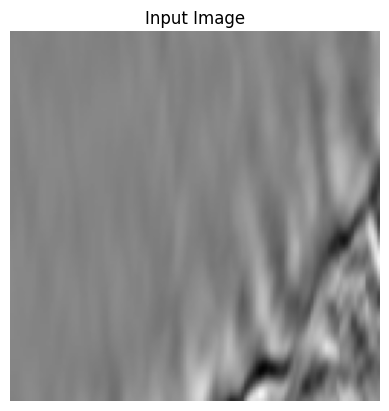

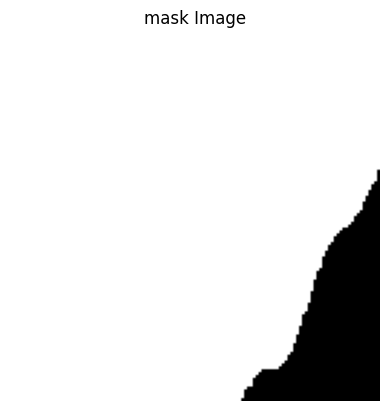

torch.Size([1, 1, 128, 128])


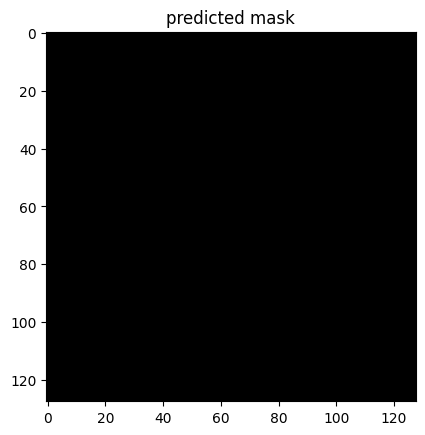

In [36]:

from matplotlib import pyplot as plt
import torch

from data.base_loader import SegmentationDataset
import os


BASE_DIR = os.getcwd()
print("BASE_DIR:", BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "../dataset/train")
print("DATA_DIR:", DATA_DIR)

dataset = SegmentationDataset(root_dir=DATA_DIR, img_size=(128, 128))
# dataset = SegmentationDataset(root_dir=DATA_DIR, img_size=(128, 128))

# -------------------------
# GET DATA SAMPLE
# -------------------------
x, y = dataset[1000]   # shape: [3, 128, 128]

print("x:", x.min().item(), x.max().item())
print("y:", y.min().item(), y.max().item())

img = x.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
mask = y.permute(1, 2, 0).cpu().numpy()  # [H, W, C]

plt.imshow(img,cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.show()
plt.imshow(mask,cmap="gray")
plt.title("mask Image")
plt.axis("off")

plt.show()
# -------------------------
# ADD BATCH DIMENSION
# -------------------------
x = x.unsqueeze(0)   # now: [1, 3, 128, 128]

# -------------------------
# DEVICE SAFETY
# -------------------------
x = x.cpu()

# -------------------------
# INFERENCE
# -------------------------
with torch.no_grad():
    pred = model(x)

print(pred.shape)
plt.imshow(pred.squeeze().cpu(),cmap="gray")
plt.title("predicted mask")
plt.show()